# Anpassning av fyrparametrig logistisk dos-responskurva med PROC NLIN

## Sammanfattning

I denna notebook anpassas en fyrparametrig logistisk (4PL) dos-responsmodell till en syntetisk cellbaserad potensbioanalys med **PROC NLIN**. Vi skattar den nedre och övre asymptoten, EC50 (den halvmaximala effektiva koncentrationen) samt Hill-lutningen. 4PL är standardmodellen för relativa potensanalyser inom läkemedelsutveckling, och denna notebook går igenom modellspecifikation, parametergränser, konvergensdiagnostik och hur den anpassade sigmoidkurvan läggs över de observerade koncentrations-responsdata.

## Datakällor

Denna notebook genererar en syntetisk datamängd inline; ingen extern indata eller nätverksdata används.

**`assay` — syntetisk cellbaserad potensbioanalys (24 rader)**

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `lot` | num | Läkemedelssubstansens sats (1-3); tre replikatkörningar av utspädningsserien |
| `dose` | num | Substanskoncentration i nmol/L över en 8-punkters seriell utspädning (0.1 till ~1000) |
| `logdose` | num | 10-logaritmen av `dose`, används för plottning på den konventionella log-koncentrationsaxeln |
| `response` | num | Uppmätt analyssignal (procent av maximal respons), genererad från en sann 4PL-kurva (botten=5, topp=100, EC50=25 nmol/L, Hill-lutning=1.2) plus proportionellt Gaussiskt brus |

De sanna genererande parametrarna är inbyggda i DATA step så att de återvunna NLIN-skattningarna kan rimlighetskontrolleras mot känt facit.

# Anpassning av fyrparametrig logistisk dos-responskurva

I farmaceutiska potens- och bioaktivitetsanalyser är sambandet mellan substanskoncentration och uppmätt respons karakteristiskt sigmoidalt på en log-koncentrationsskala. Den **fyrparametriga logistiska (4PL)** modellen är standardverktyget för att sammanfatta sådana kurvor:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

där

- **A** = nedre asymptot (respons vid oändlig utspädning / baslinjesignal),
- **D** = övre asymptot (maximal respons vid mättande koncentration),
- **C** = **EC50**, den koncentration som ger halvmaximal respons (inflexionspunkten och den primära potensavläsningen),
- **B** = **Hill-lutningen**, som styr övergångens branthet.

Denna modell är icke-linjär i sina parametrar, så vi anpassar den med iterativ minsta-kvadratmetod via `PROC NLIN`. Nedan simulerar vi en realistisk åttapunkters utspädningsserie körd i triplikat, anpassar 4PL-kurvan, begränsar parametrarna till fysiskt meningsfulla områden, granskar konvergens- och anpassningsdiagnostik och lägger den anpassade kurvan över data.

## Steg 1 — Simulera en cellbaserad potensbioanalys

Vi genererar en syntetisk datamängd från en *känd* 4PL-kurva (botten = 5, topp = 100, EC50 = 25 nmol/L, Hill-lutning = 1.2) så att de parametrar som NLIN återvinner kan jämföras mot det sanna facit. Tre satser får var och en samma åttapunkters seriella utspädning (varje steg en 3.5-faldig utspädning), med proportionellt Gaussiskt mätbrus pålagt. Ett fast `streaminit`-frö gör simuleringen reproducerbar.

In [1]:
data assay;
    CALL streaminit(40521);

    /* Sanna 4PL-parametrar som används för att generera data */
    A_true   = 5;      /* nedre asymptot (baslinje)        */
    D_true   = 100;    /* övre asymptot (max respons)      */
    C_true   = 25;     /* EC50 i nmol/L                    */
    B_true   = 1.2;    /* Hill-lutning                     */

    GÖR lot = 1 TILL 3;
        /* Åttapunkters seriell utspädning, 3,5-faldiga steg */
        dose = 0.30;
        GÖR point = 1 TILL 8;
            dose = dose * 3.5;

            /* Brusfri 4PL-medelrespons */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proportionellt + additivt Gaussiskt mätbrus */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            UTDATA;
        SLUT;
    SLUT;

    BEHÅLL lot dose logdose response;
KÖR;

PROC SORT data=assay;
    EFTER dose lot;
KÖR;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Steg 2 — Visualisera rådata för koncentration-respons

Innan anpassningen plottar vi respons mot log10(dose) för att bekräfta den förväntade sigmoidala formen och för att avläsa grova startvärden: kurvan bottnar nära 5, planar ut nära 100, och mittpunkten (halvmaximal respons) ligger runt log10(25) ≈ 1.4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


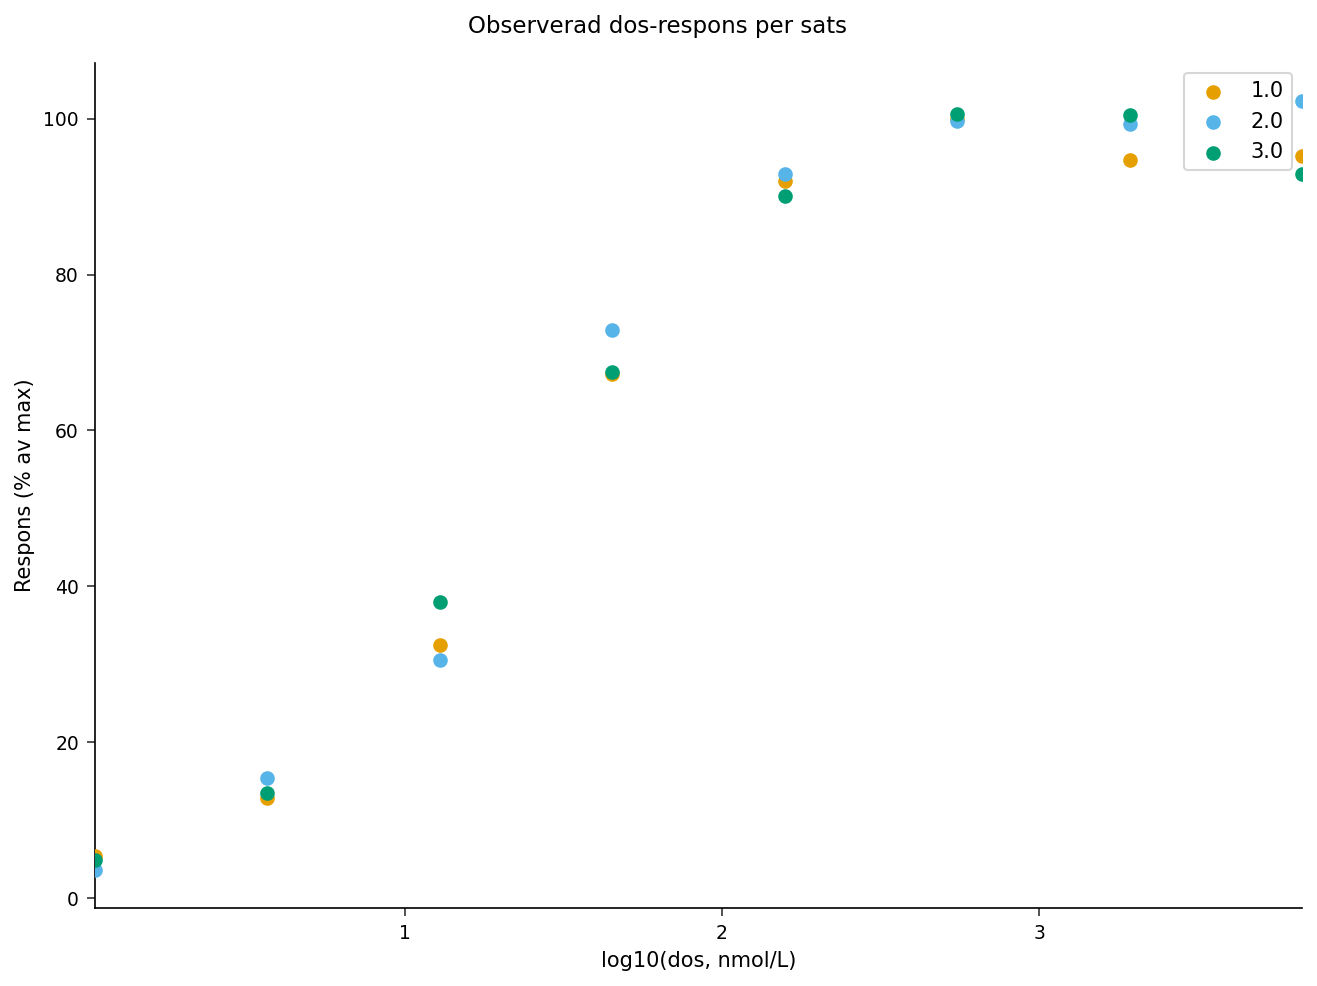

In [2]:
PROC SGPLOT data=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS ETIKETT="log10(dos, nmol/L)";
    YAXIS ETIKETT="Respons (% av max)";
    TITEL "Observerad dos-respons per sats";
KÖR;
TITEL;


## Steg 3 — Anpassa 4PL-modellen med PROC NLIN

Vi anger startvärden med `PARMS` (utifrån spridningsdiagrammet), definierar 4PL-medelvärdet i en mellanliggande tilldelning och skickar det till `MODEL`-satsen. Fysiskt meningsfulla `BOUNDS` håller asymptoterna ordnade och EC50 och lutningen positiva, vilket stabiliserar Gauss-Newton-iterationerna. `OUTPUT`-satsen sparar predikterade värden, residualer och konfidensgränser för senare diagnostik, och `PLOTS=` begär anpassnings- och diagnostikpanelerna.

In [3]:
PROC NLIN data=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Håll parametrarna inom fysiskt rimliga intervall */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Fyrparametrig logistisk medelrespons (inline: Jenner PROC NLIN
       stöder ännu inte referens till en mellanliggande programsats-
       variabel i MODEL -- se tests/400986 -- så vi klistrar in
       nämnaren direkt) */
    MODEL response = D + (A - D) / (1 + (dose / C) ** B);

    ETIKETT response="Respons (% av max)" dose="Dos (nmol/L)";

    UTDATA out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
KÖR;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/de0011c5-8c5c-4993-9bea-266df5368f2c/fit4pl.avro


## Steg 4 — Rapportera skattad EC50 och kurvans egenskaper

`OUTEST=`-mekanismen är bekväm, men för en snabb potensavläsning sammanfattar vi den anpassade kurvan direkt. Här listar vi de anpassade värdena vid varje dos tillsammans med de observerade responserna för att bekräfta att modellen följer data över hela utspädningsintervallet.

In [4]:
PROC MEANS data=fit4pl mean std MIN MAX maxdec=3;
    KLASS dose;
    VARIABEL response pred resid;
    ETIKETT dose="Dos (nmol/L)"
            response="Respons (% av max)"
            pred="Predikterad respons"
            resid="Residual";
    TITEL "Observerad kontra anpassad respons per dos";
KÖR;
TITEL;


                                       Observerad kontra anpassad respons per dos                                       

                                                  The MEANS Procedure

                                   Analysis Variable : RESPONSE Respons (% av max)

                                           N
                       Dos (nmol/L)      Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.393


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Steg 5 — Lägg den anpassade 4PL-kurvan över observerade data

Ett tätt prediktionsrutnät ger en jämn anpassad sigmoidkurva. Vi kombinerar den jämna kurvan med de dosvisa genomsnittliga anpassade värdena och konfidensbandet, och lägger sedan allt över de observerade punkterna för att bedöma anpassningens godhet visuellt.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


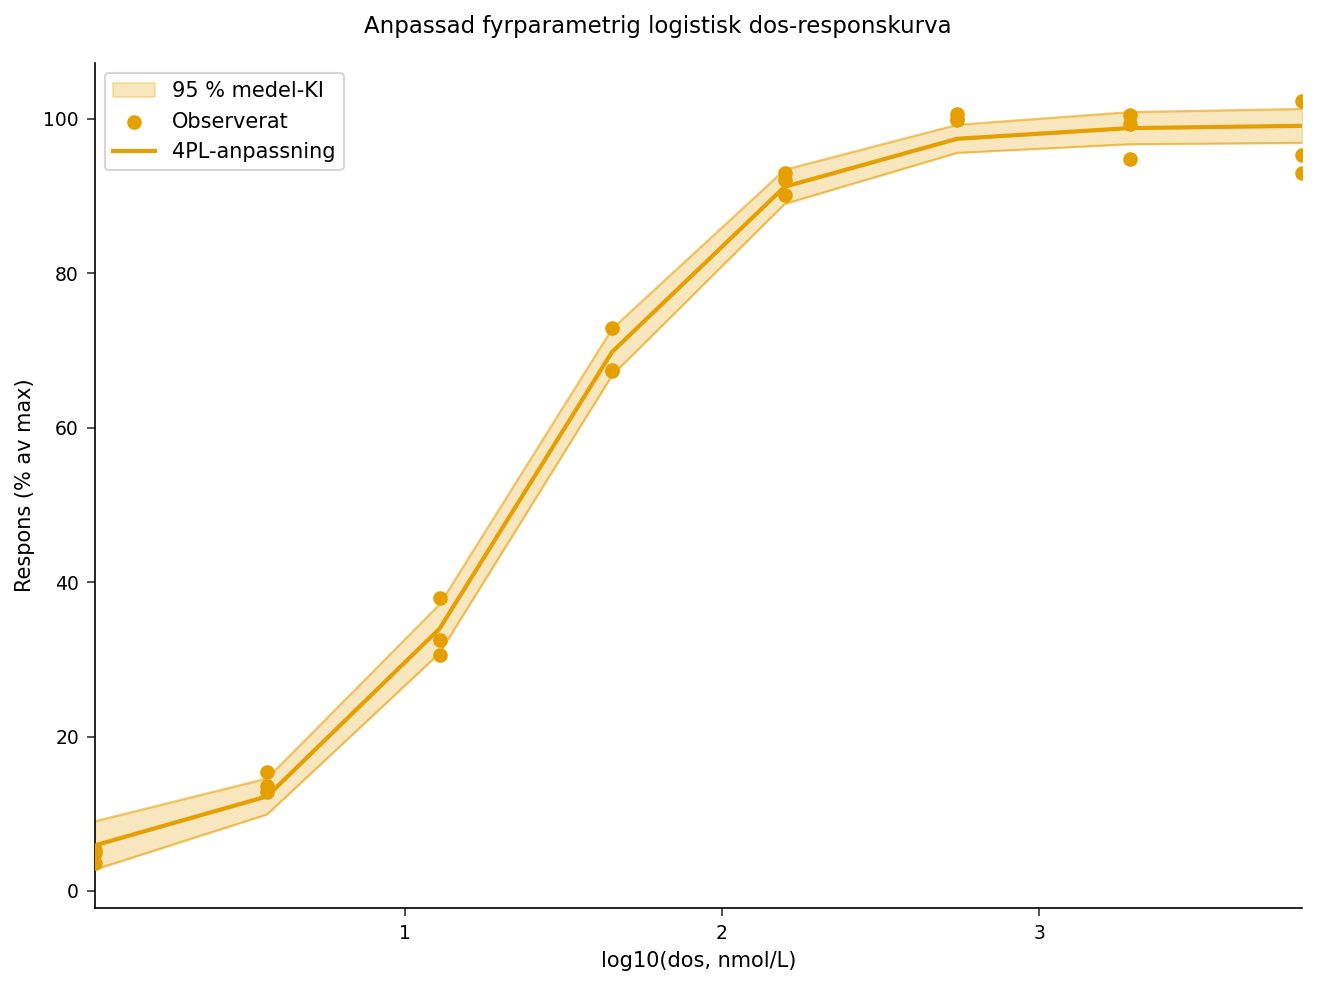

In [5]:
PROC SORT data=fit4pl;
    EFTER logdose;
KÖR;

PROC SGPLOT data=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel="95 % medel-KI";
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel="Observerat";
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel="4PL-anpassning";
    XAXIS ETIKETT="log10(dos, nmol/L)";
    YAXIS ETIKETT="Respons (% av max)";
    TITEL "Anpassad fyrparametrig logistisk dos-responskurva";
KÖR;
TITEL;


## Tolkning av resultaten

`PROC NLIN` konvergerar till skattningar nära de kända genererande värdena: en nedre asymptot nära **5**, en övre asymptot nära **100**, ett **EC50 (C)** nära **25 nmol/L** och en **Hill-lutning (B)** nära **1.2**. Att dessa parametrar återvinns ur brusiga triplikatdata bekräftar att modellen är identifierbar och att gränserna inte var bindande i optimum.

**EC50** är det centrala potensmåttet: lägre värden indikerar en mer potent substans, och i en relativ potensanalys jämförs testsatsens EC50 mot en referensstandard. **Hill-lutningen** karakteriserar kooperativitet och analysens branthet — en lutning nära 1 är förenlig med enkel bindning till en enda plats. **Asymptoterna** definierar analysens dynamiska omfång; en stabil, väl separerad botten och topp är förutsättningar för en validerbar bioanalys.

Anpassningsdiagrammet visar sigmoidkurvan som passerar genom molnet av observerade punkter med ett smalt 95 % konfidensband för medelvärdet genom det responsiva området, och residualdiagnostiken bör inte visa någon systematisk krökning — vilket är tecken på att 4PL-formen är adekvat. I praktiken skulle du utöka detta arbetsflöde med `PROFILE`-likelihoodintervall för EC50, en `BOOTSTRAP`-sats för fördelningsfri parameterinferens, eller en parallell-linjeanalys som jämför test- och referenssatser för att skatta relativ potens.